# 07 — QSVM Experiments
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Evaluate Quantum Support Vector Machines (QSVM) for physiological stress classification
under LOSO cross-validation on WESAD and DREAMER. QSVM extends classical SVM by
replacing the RBF kernel with a quantum kernel derived from a quantum feature map.

## How QSVM Works
1. Classical feature vector x is encoded into a quantum state |phi(x)> via a feature map circuit
2. Similarity between two samples is computed as the quantum kernel: K(xi, xj) = |<phi(xi)|phi(xj)>|^2
3. This kernel matrix replaces the classical RBF kernel in a standard SVM
4. Classification proceeds via the SVM decision function

## Experimental Grid
| Factor | Values |
|--------|--------|
| Feature map | ZZFeatureMap, PauliFeatureMap |
| Entanglement | linear, full, circular |
| Repetitions | 1, 2 |
| PCA components | 3, 4 (WESAD) / 4, 6 (DREAMER)|

## Data Conditions (matching classical baselines)
- Stratified subsample: 150 windows per class per fold (train only)
- PCA fitted on train fold only
- StandardScaler fitted on train fold only
- Test set: all windows for held-out subject

## Datasets & Tasks
- WESAD binary (baseline vs stress)
- WESAD 3-class (baseline vs stress vs amusement)
- DREAMER binary EEG (low vs high arousal)

---


## 0. Configuration

In [34]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
from itertools import product

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

from qiskit.circuit.library import ZZFeatureMap, PauliFeatureMap
from qiskit_machine_learning.kernels import FidelityStatevectorKernel

warnings.filterwarnings('ignore')

# ── Results folders ───────────────────────────────────────────────────────────
RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '07_qsvm')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

# ── General config ────────────────────────────────────────────────────────────
ECG_FEATURE_PREFIXES = ['ecg_']
RANDOM_STATE         = 42
N_SAMPLES_PER_CLASS  = 150

# ── QSVM experiment grid ──────────────────────────────────────────────────────
PCA_COMPONENTS_WESAD   = [3, 4]     # 60.5% and 70.6% variance explained
PCA_COMPONENTS_DREAMER = [4, 6]     # 59.4% and 70.0% variance explained
REPS_LIST              = [1, 2]
ENTANGLEMENTS          = ['linear', 'full', 'circular']
SCALER_NAMES           = ['standard', 'robust']
FEATURE_MAPS           = ['ZZFeatureMap', 'PauliFeatureMap']

# ── Config counts ─────────────────────────────────────────────────────────────
n_configs_wesad   = len(PCA_COMPONENTS_WESAD)   * len(REPS_LIST) * len(ENTANGLEMENTS) * len(FEATURE_MAPS) * len(SCALER_NAMES)
n_configs_dreamer = len(PCA_COMPONENTS_DREAMER)  * len(REPS_LIST) * len(ENTANGLEMENTS) * len(FEATURE_MAPS) * len(SCALER_NAMES)
n_configs_total   = n_configs_wesad * 2 + n_configs_dreamer  # x2 for binary + 3class on WESAD

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Feature maps             : {FEATURE_MAPS}')
print(f'  PCA components (WESAD)   : {PCA_COMPONENTS_WESAD}')
print(f'  PCA components (DREAMER) : {PCA_COMPONENTS_DREAMER}')
print(f'  Repetitions              : {REPS_LIST}')
print(f'  Entanglements            : {ENTANGLEMENTS}')
print(f'  Scalers (pre-PCA)        : {SCALER_NAMES}')
print(f'  Post-PCA scaler          : MinMax(-pi, pi) fixed')
print(f'  Subsample                : {N_SAMPLES_PER_CLASS} per class per fold')
print(f'  WESAD configs (per task) : {n_configs_wesad}')
print(f'  DREAMER configs          : {n_configs_dreamer}')
print(f'  Total configs overall    : {n_configs_total}')

Configuration ready.
  Feature maps             : ['ZZFeatureMap', 'PauliFeatureMap']
  PCA components (WESAD)   : [3, 4]
  PCA components (DREAMER) : [4, 6]
  Repetitions              : [1, 2]
  Entanglements            : ['linear', 'full', 'circular']
  Scalers (pre-PCA)        : ['standard', 'robust']
  Post-PCA scaler          : MinMax(-pi, pi) fixed
  Subsample                : 150 per class per fold
  WESAD configs (per task) : 48
  DREAMER configs          : 48
  Total configs overall    : 144


## 1. Load Datasets

In [35]:
# WESAD
df_wesad_bin = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_binary.csv'))
df_wesad_3cl = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_3class.csv'))
wesad_feat_cols = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')))

# DREAMER — EEG features only
df_dreamer = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv'))
dreamer_all_feats = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'dreamer_feature_columns.json')))
dreamer_eeg_feats = [c for c in dreamer_all_feats
                     if not any(c.startswith(p) for p in ECG_FEATURE_PREFIXES)]

print('=== Datasets Loaded ===')
print(f'WESAD binary   : {df_wesad_bin.shape}  features={len(wesad_feat_cols)}')
print(f'WESAD 3-class  : {df_wesad_3cl.shape}')
print(f'DREAMER binary : {df_dreamer.shape}  EEG features={len(dreamer_eeg_feats)}')


=== Datasets Loaded ===
WESAD binary   : (883, 30)  features=26
WESAD 3-class  : (1049, 30)
DREAMER binary : (414, 146)  EEG features=134


In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Check PCA variance explained on WESAD
X_all = df_wesad_bin[wesad_feat_cols].values.astype(float)
imp   = SimpleImputer(strategy='median')
X_all = imp.fit_transform(X_all)
X_all = StandardScaler().fit_transform(X_all)

for n in [3, 4, 6, 8, 10]:
    pca = PCA(n_components=n)
    pca.fit(X_all)
    print(f'  PCA n={n:2d}: variance explained = {pca.explained_variance_ratio_.sum()*100:.1f}%')

  PCA n= 3: variance explained = 60.5%
  PCA n= 4: variance explained = 70.6%
  PCA n= 6: variance explained = 81.7%
  PCA n= 8: variance explained = 89.3%
  PCA n=10: variance explained = 94.0%


In [17]:
X_dr  = df_dreamer[dreamer_eeg_feats].values.astype(float)
X_dr  = SimpleImputer(strategy='median').fit_transform(X_dr)
X_dr  = StandardScaler().fit_transform(X_dr)

for n in [3, 4, 6, 8, 10]:
    pca = PCA(n_components=n)
    pca.fit(X_dr)
    print(f'  DREAMER PCA n={n:2d}: variance explained = {pca.explained_variance_ratio_.sum()*100:.1f}%')

  DREAMER PCA n= 3: variance explained = 53.1%
  DREAMER PCA n= 4: variance explained = 59.4%
  DREAMER PCA n= 6: variance explained = 70.0%
  DREAMER PCA n= 8: variance explained = 75.5%
  DREAMER PCA n=10: variance explained = 79.3%


## 2. Utilities

In [36]:
def stratified_subsample(X, y, n_per_class, random_state=42):
    X_parts, y_parts = [], []
    rng = np.random.RandomState(random_state)
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        chosen = idx if len(idx) <= n_per_class \
                 else rng.choice(idx, size=n_per_class, replace=False)
        X_parts.append(X[chosen])
        y_parts.append(y[chosen])
    X_out = np.vstack(X_parts)
    y_out = np.concatenate(y_parts)
    perm  = rng.permutation(len(y_out))
    return X_out[perm], y_out[perm]


def compute_metrics(y_true, y_pred, average='macro'):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred,
                           average=average, zero_division=0)),
    }


def build_feature_map(name, n_qubits, reps, entanglement):
    """Build a Qiskit feature map circuit."""
    if name == 'ZZFeatureMap':
        return ZZFeatureMap(
            feature_dimension=n_qubits,
            reps=reps,
            entanglement=entanglement
        )
    elif name == 'PauliFeatureMap':
        return PauliFeatureMap(
            feature_dimension=n_qubits,
            reps=reps,
            entanglement=entanglement,
            paulis=['Z', 'ZZ']
        )
    else:
        raise ValueError(f'Unknown feature map: {name}')


print('Utilities defined.')


Utilities defined.


## 3. QSVM LOSO Pipeline
Runs one QSVM configuration (feature map + entanglement + reps + PCA) across all LOSO folds.

In [31]:
def run_qsvm_loso(df, feature_cols, label_col, subject_col,
                  feature_map_name, n_qubits, reps, entanglement, scaler_name,
                  task_name, average='macro',
                  n_per_class=N_SAMPLES_PER_CLASS):
    """
    LOSO cross-validation for one QSVM configuration.
    Returns DataFrame of per-fold results and accumulated confusion matrix.
    """
    subjects = sorted(df[subject_col].unique())
    classes  = sorted(df[label_col].unique())
    n_cls    = len(classes)

    fold_rows = []
    cm_accum  = np.zeros((n_cls, n_cls), dtype=int)

    config_str = (f'{feature_map_name}_n{n_qubits}_'
                  f'r{reps}_{entanglement}_{scaler_name}')

    for fold_i, test_sid in enumerate(subjects):
        train_mask = df[subject_col] != test_sid
        test_mask  = df[subject_col] == test_sid

        X_train = df.loc[train_mask, feature_cols].values.astype(float)
        y_train = df.loc[train_mask, label_col].values
        X_test  = df.loc[test_mask,  feature_cols].values.astype(float)
        y_test  = df.loc[test_mask,  label_col].values

        # Impute — train only
        imputer = SimpleImputer(strategy='median')
        X_train = imputer.fit_transform(X_train)
        X_test  = imputer.transform(X_test)

        # Subsample train
        X_tr, y_tr = stratified_subsample(
            X_train, y_train, n_per_class,
            random_state=RANDOM_STATE + fold_i)

        # Scale before PCA — varies across grid
        if scaler_name == 'standard':
            scaler = StandardScaler()
        else:
            scaler = RobustScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_test)

        # PCA — fit on train only
        pca  = PCA(n_components=n_qubits, random_state=RANDOM_STATE)
        X_tr = pca.fit_transform(X_tr)
        X_te = pca.transform(X_te)

        # Scale after PCA — always MinMax(-π, π) for quantum angle encoding
        scaler2 = MinMaxScaler(feature_range=(-np.pi, np.pi))
        X_tr    = scaler2.fit_transform(X_tr)
        X_te    = scaler2.transform(X_te)

        # Build quantum kernel
        try:
            fm     = build_feature_map(feature_map_name, n_qubits,
                                        reps, entanglement)
            kernel = FidelityStatevectorKernel(feature_map=fm)

            # Compute kernel matrices
            t0        = time.time()
            K_train   = kernel.evaluate(x_vec=X_tr)
            K_test    = kernel.evaluate(x_vec=X_te, y_vec=X_tr)
            kernel_time = time.time() - t0

            # Fit SVM with precomputed kernel
            t1  = time.time()
            svm = SVC(kernel='precomputed', class_weight='balanced')
            svm.fit(K_train, y_tr)
            train_time = time.time() - t1 + kernel_time

            t2     = time.time()
            y_pred = svm.predict(K_test)
            test_time = time.time() - t2

            metrics = compute_metrics(y_test, y_pred, average=average)
            cm      = confusion_matrix(y_test, y_pred, labels=classes)
            cm_accum += cm
            status  = 'ok'

        except Exception as e:
            metrics    = {'accuracy':np.nan,'precision':np.nan,
                          'recall':np.nan,'f1':np.nan}
            train_time = np.nan
            test_time  = np.nan
            status     = f'error: {str(e)[:60]}'

        fold_rows.append({
            'task'            : task_name,
            'feature_map'     : feature_map_name,
            'n_qubits'        : n_qubits,
            'reps'            : reps,
            'entanglement'    : entanglement,
            'scaler'          : scaler_name,
            'config'          : config_str,
            'fold'            : fold_i + 1,
            'test_subject'    : int(test_sid),
            'train_time'      : round(train_time, 2) if not np.isnan(train_time) else np.nan,
            'test_time'       : round(test_time, 4)  if not np.isnan(test_time)  else np.nan,
            'status'          : status,
            **metrics
        })

    return pd.DataFrame(fold_rows), cm_accum


print('QSVM LOSO pipeline defined.')


QSVM LOSO pipeline defined.


## 4. Run QSVM Grid Search — WESAD Binary
> Runs all feature map / entanglement / reps / PCA combinations.
> With 150 samples/class this should take 15-40 minutes total.

In [38]:
from tqdm.notebook import tqdm

def run_full_grid(df, feature_cols, label_col, subject_col,
                  task_name,pca_components, average='macro'):
    """
    Run the full QSVM grid across all configurations.
    Returns combined results DataFrame and best config confusion matrix.
    """
    all_rows  = []
    best_f1   = -1
    best_cm   = None
    best_cfg  = None

    configs = list(product(FEATURE_MAPS, pca_components,
                           REPS_LIST, ENTANGLEMENTS, SCALER_NAMES))
    print(f'Total configurations: {len(configs)}')
    print(f'Task: {task_name}\n')

    for i, (fm_name, n_q, reps, ent, scaler_name) in enumerate(configs):
        cfg_str = f'{fm_name} | n_qubits={n_q} | reps={reps} | {ent} | {scaler_name}'
        print(f'[{i+1:2d}/{len(configs)}] {cfg_str}')

        t_start = time.time()
        fold_df, cm = run_qsvm_loso(
            df=df, feature_cols=feature_cols,
            label_col=label_col, subject_col=subject_col,
            feature_map_name=fm_name, n_qubits=n_q,
            reps=reps, entanglement=ent,
            scaler_name=scaler_name,
            task_name=task_name, average=average
        )
        elapsed = time.time() - t_start

        mean_f1 = fold_df['f1'].mean()
        mean_acc = fold_df['accuracy'].mean()
        all_rows.append(fold_df)

        if mean_f1 > best_f1:
            best_f1  = mean_f1
            best_cm  = cm
            best_cfg = cfg_str

        print(f'         mean_acc={mean_acc:.4f}  '
              f'mean_f1={mean_f1:.4f}  '
              f'total_time={elapsed:.0f}s')

    results_df = pd.concat(all_rows, ignore_index=True)
    print(f'\nBest config : {best_cfg}')
    print(f'Best mean F1: {best_f1:.4f}')
    return results_df, best_cm, best_cfg


print('Grid search function defined. Starting WESAD binary...')
results_wb, best_cm_wb, best_cfg_wb = run_full_grid(
    df           = df_wesad_bin,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_binary_QSVM',
    pca_components = PCA_COMPONENTS_WESAD

)


Grid search function defined. Starting WESAD binary...
Total configurations: 48
Task: WESAD_binary_QSVM

[ 1/48] ZZFeatureMap | n_qubits=3 | reps=1 | linear | standard
         mean_acc=0.5602  mean_f1=0.5303  total_time=11s
[ 2/48] ZZFeatureMap | n_qubits=3 | reps=1 | linear | robust
         mean_acc=0.6413  mean_f1=0.6198  total_time=37s
[ 3/48] ZZFeatureMap | n_qubits=3 | reps=1 | full | standard
         mean_acc=0.5158  mean_f1=0.4976  total_time=72s
[ 4/48] ZZFeatureMap | n_qubits=3 | reps=1 | full | robust
         mean_acc=0.6315  mean_f1=0.6103  total_time=43s
[ 5/48] ZZFeatureMap | n_qubits=3 | reps=1 | circular | standard
         mean_acc=0.5158  mean_f1=0.4976  total_time=39s
[ 6/48] ZZFeatureMap | n_qubits=3 | reps=1 | circular | robust
         mean_acc=0.6315  mean_f1=0.6103  total_time=40s
[ 7/48] ZZFeatureMap | n_qubits=3 | reps=2 | linear | standard
         mean_acc=0.5302  mean_f1=0.5122  total_time=45s
[ 8/48] ZZFeatureMap | n_qubits=3 | reps=2 | linear | robust


## 5. WESAD 3-Class Task

In [39]:
print('Starting WESAD 3-class...')
results_w3, best_cm_w3, best_cfg_w3 = run_full_grid(
    df           = df_wesad_3cl,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_3class_QSVM',
    average      = 'macro',
    pca_components = PCA_COMPONENTS_WESAD

)


Starting WESAD 3-class...
Total configurations: 48
Task: WESAD_3class_QSVM

[ 1/48] ZZFeatureMap | n_qubits=3 | reps=1 | linear | standard
         mean_acc=0.3802  mean_f1=0.3515  total_time=19s
[ 2/48] ZZFeatureMap | n_qubits=3 | reps=1 | linear | robust
         mean_acc=0.4099  mean_f1=0.3871  total_time=19s
[ 3/48] ZZFeatureMap | n_qubits=3 | reps=1 | full | standard
         mean_acc=0.3475  mean_f1=0.3274  total_time=21s
[ 4/48] ZZFeatureMap | n_qubits=3 | reps=1 | full | robust
         mean_acc=0.4156  mean_f1=0.3781  total_time=20s
[ 5/48] ZZFeatureMap | n_qubits=3 | reps=1 | circular | standard
         mean_acc=0.3475  mean_f1=0.3274  total_time=20s
[ 6/48] ZZFeatureMap | n_qubits=3 | reps=1 | circular | robust
         mean_acc=0.4156  mean_f1=0.3781  total_time=20s
[ 7/48] ZZFeatureMap | n_qubits=3 | reps=2 | linear | standard
         mean_acc=0.3774  mean_f1=0.3527  total_time=23s
[ 8/48] ZZFeatureMap | n_qubits=3 | reps=2 | linear | robust
         mean_acc=0.4094  mea

## 6. DREAMER Binary EEG Task

In [40]:
print('Starting DREAMER binary EEG...')
results_db, best_cm_db, best_cfg_db = run_full_grid(
    df           = df_dreamer,
    feature_cols = dreamer_eeg_feats,
    label_col    = 'arousal_binary',
    subject_col  = 'subject_id',
    task_name    = 'DREAMER_binary_EEG_QSVM',
    average      = 'macro',
    pca_components = PCA_COMPONENTS_DREAMER

)


Starting DREAMER binary EEG...
Total configurations: 48
Task: DREAMER_binary_EEG_QSVM

[ 1/48] ZZFeatureMap | n_qubits=4 | reps=1 | linear | standard
         mean_acc=0.5290  mean_f1=0.4460  total_time=17s
[ 2/48] ZZFeatureMap | n_qubits=4 | reps=1 | linear | robust
         mean_acc=0.4807  mean_f1=0.3566  total_time=17s
[ 3/48] ZZFeatureMap | n_qubits=4 | reps=1 | full | standard
         mean_acc=0.5121  mean_f1=0.4510  total_time=19s
[ 4/48] ZZFeatureMap | n_qubits=4 | reps=1 | full | robust
         mean_acc=0.4758  mean_f1=0.3625  total_time=19s
[ 5/48] ZZFeatureMap | n_qubits=4 | reps=1 | circular | standard
         mean_acc=0.5072  mean_f1=0.4436  total_time=17s
[ 6/48] ZZFeatureMap | n_qubits=4 | reps=1 | circular | robust
         mean_acc=0.4831  mean_f1=0.3680  total_time=17s
[ 7/48] ZZFeatureMap | n_qubits=4 | reps=2 | linear | standard
         mean_acc=0.5290  mean_f1=0.4625  total_time=21s
[ 8/48] ZZFeatureMap | n_qubits=4 | reps=2 | linear | robust
         mean_acc=

## 7. Results Summary

In [41]:
all_results = pd.concat([results_wb, results_w3, results_db], ignore_index=True)

# Best config per task
print('=== BEST QSVM CONFIGURATION PER TASK ===')
best_per_task = (
    all_results
    .groupby(['task','config','feature_map','n_qubits','reps','entanglement'])
    .agg(f1_mean=('f1','mean'), f1_std=('f1','std'),
         acc_mean=('accuracy','mean'),
         train_time_mean=('train_time','mean'))
    .reset_index()
    .sort_values(['task','f1_mean'], ascending=[True, False])
)

for task in best_per_task['task'].unique():
    print(f'\n  {task}:')
    top = best_per_task[best_per_task['task']==task].head(3)
    print(top[['config','f1_mean','f1_std','acc_mean',
                'train_time_mean']].round(4).to_string(index=False))

# Full summary by feature map
print('\n=== QSVM SUMMARY BY FEATURE MAP ===')
fm_summary = (
    all_results
    .groupby(['task','feature_map'])
    .agg(f1_mean=('f1','mean'), f1_std=('f1','std'),
         acc_mean=('accuracy','mean'),
         train_time_mean=('train_time','mean'))
    .round(4)
    .reset_index()
)
print(fm_summary.to_string(index=False))

# Save
p = os.path.join(OUTPUT_DATA_DIR, 'qsvm_all_results.csv')
all_results.to_csv(p, index=False)
print(f'\nSaved all results: {p}')

p2 = os.path.join(OUTPUT_DATA_DIR, 'qsvm_best_per_task.csv')
best_per_task.to_csv(p2, index=False)
print(f'Saved best configs: {p2}')


=== BEST QSVM CONFIGURATION PER TASK ===

  DREAMER_binary_EEG_QSVM:
                               config  f1_mean  f1_std  acc_mean  train_time_mean
  PauliFeatureMap_n6_r2_full_standard   0.4999  0.1299    0.5217           1.9196
     ZZFeatureMap_n6_r2_full_standard   0.4999  0.1299    0.5217           1.9278
PauliFeatureMap_n4_r2_linear_standard   0.4625  0.1139    0.5290           0.8883

  WESAD_3class_QSVM:
                               config  f1_mean  f1_std  acc_mean  train_time_mean
PauliFeatureMap_n3_r2_circular_robust   0.3898  0.1739     0.423           1.6060
    PauliFeatureMap_n3_r2_full_robust   0.3898  0.1739     0.423           1.5800
   ZZFeatureMap_n3_r2_circular_robust   0.3898  0.1739     0.423           7.0807

  WESAD_binary_QSVM:
                               config  f1_mean  f1_std  acc_mean  train_time_mean
  PauliFeatureMap_n3_r1_linear_robust   0.6198  0.1954    0.6413           0.6547
     ZZFeatureMap_n3_r1_linear_robust   0.6198  0.1954    0.6413   

## 8. Plots

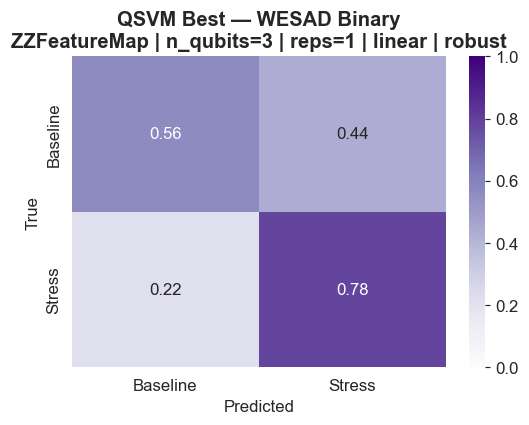

Saved: ..\results\plots\07_qsvm\cm_qsvm_wesad_binary_best.png


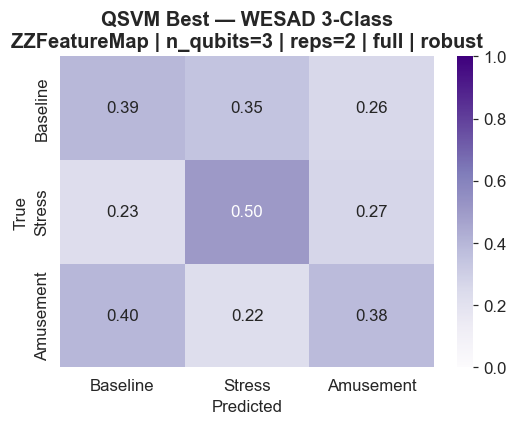

Saved: ..\results\plots\07_qsvm\cm_qsvm_wesad_3class_best.png


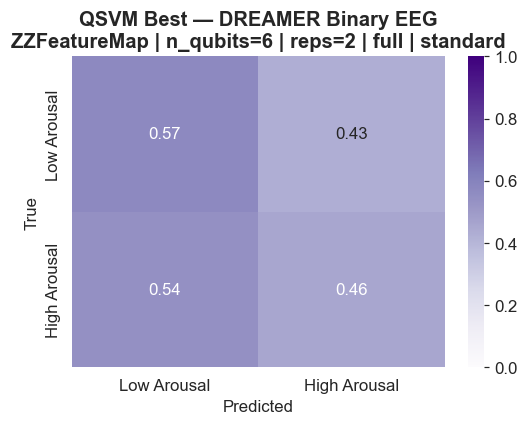

Saved: ..\results\plots\07_qsvm\cm_qsvm_dreamer_binary_best.png


In [42]:
# Best confusion matrices
def plot_cm(cm, class_names, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1, annot_kws={'size':11})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_cm(best_cm_wb, ['Baseline','Stress'],
        f'QSVM Best — WESAD Binary\n{best_cfg_wb}',
        os.path.join(PLOTS_DIR, 'cm_qsvm_wesad_binary_best.png'))

plot_cm(best_cm_w3, ['Baseline','Stress','Amusement'],
        f'QSVM Best — WESAD 3-Class\n{best_cfg_w3}',
        os.path.join(PLOTS_DIR, 'cm_qsvm_wesad_3class_best.png'))

plot_cm(best_cm_db, ['Low Arousal','High Arousal'],
        f'QSVM Best — DREAMER Binary EEG\n{best_cfg_db}',
        os.path.join(PLOTS_DIR, 'cm_qsvm_dreamer_binary_best.png'))


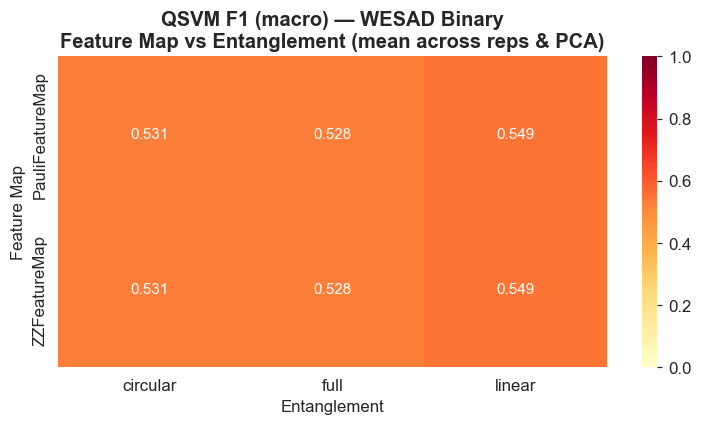

Saved: ..\results\plots\07_qsvm\qsvm_f1_heatmap_wesad_binary_qsvm.png


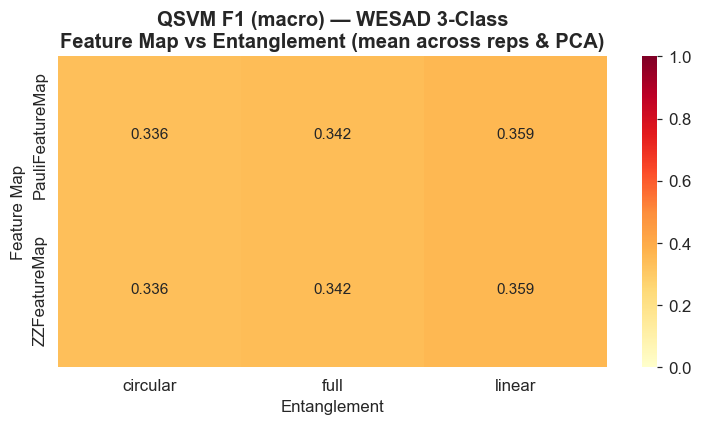

Saved: ..\results\plots\07_qsvm\qsvm_f1_heatmap_wesad_3class_qsvm.png


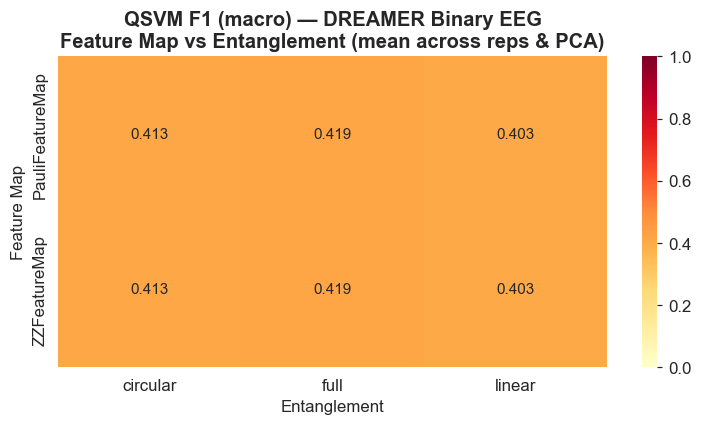

Saved: ..\results\plots\07_qsvm\qsvm_f1_heatmap_dreamer_binary_eeg_qsvm.png


In [43]:
# F1 heatmap: feature map x entanglement per task
for task_key, task_label in [
        ('WESAD_binary_QSVM',      'WESAD Binary'),
        ('WESAD_3class_QSVM',      'WESAD 3-Class'),
        ('DREAMER_binary_EEG_QSVM','DREAMER Binary EEG')]:

    td = all_results[all_results['task']==task_key]
    if len(td) == 0:
        continue

    pivot = td.groupby(['feature_map','entanglement'])['f1'].mean().unstack()
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                ax=ax, vmin=0, vmax=1, annot_kws={'size':10})
    ax.set_title(f'QSVM F1 (macro) — {task_label}\n'
                 f'Feature Map vs Entanglement (mean across reps & PCA)',
                 fontweight='bold')
    ax.set_xlabel('Entanglement')
    ax.set_ylabel('Feature Map')
    plt.tight_layout()
    fname = f'qsvm_f1_heatmap_{task_key.lower()}.png'
    p = os.path.join(PLOTS_DIR, fname)
    plt.savefig(p, bbox_inches='tight'); plt.show()
    print(f'Saved: {p}')


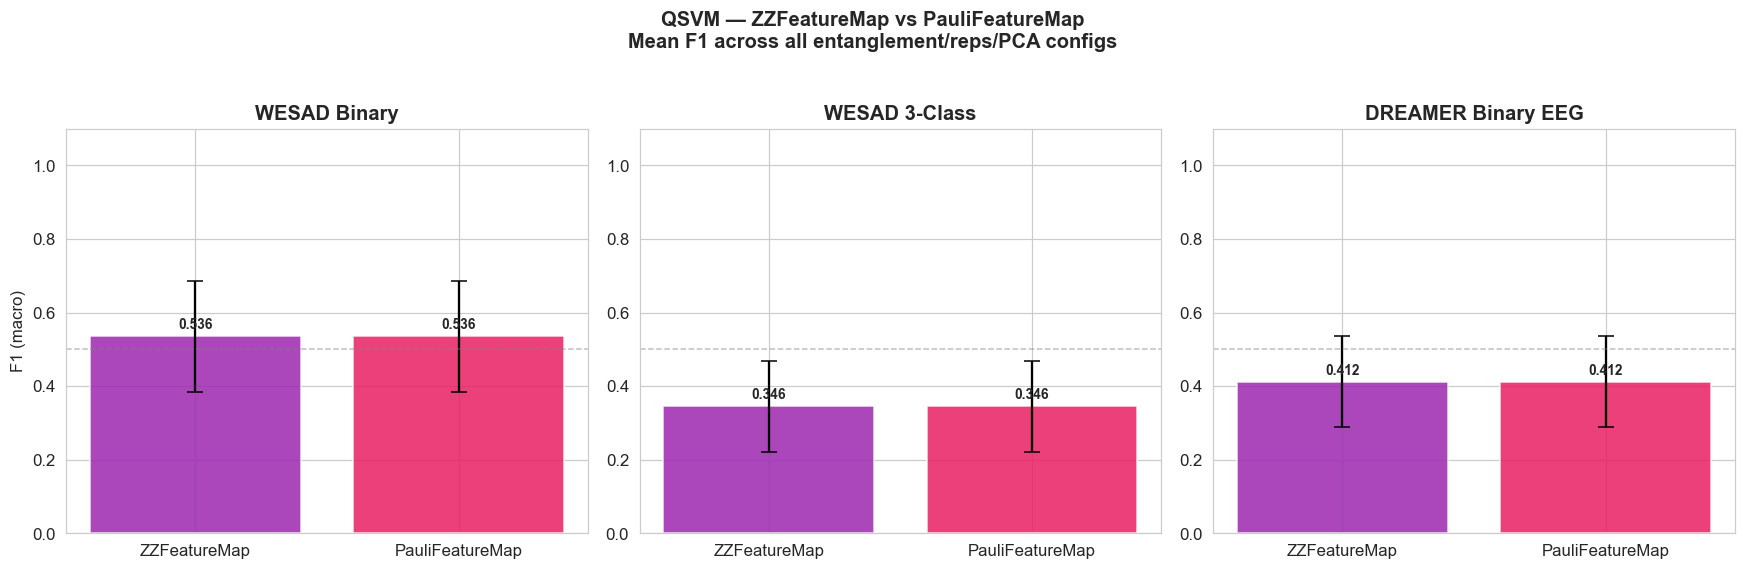

Saved: ..\results\plots\07_qsvm\qsvm_fm_comparison.png


In [44]:
# F1 comparison: ZZFeatureMap vs PauliFeatureMap across tasks
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fm_colors = {'ZZFeatureMap': '#9C27B0', 'PauliFeatureMap': '#E91E63'}

for ax, (task_key, task_label) in zip(axes, [
        ('WESAD_binary_QSVM',      'WESAD Binary'),
        ('WESAD_3class_QSVM',      'WESAD 3-Class'),
        ('DREAMER_binary_EEG_QSVM','DREAMER Binary EEG')]):

    td = all_results[all_results['task']==task_key]
    for fm in ['ZZFeatureMap','PauliFeatureMap']:
        fm_data = td[td['feature_map']==fm]['f1']
        if len(fm_data) == 0:
            continue
        ax.bar(fm, fm_data.mean(),
               color=fm_colors[fm], alpha=0.85,
               yerr=fm_data.std(), capsize=5)
        ax.text(list(fm_colors.keys()).index(fm),
                fm_data.mean() + 0.02,
                f'{fm_data.mean():.3f}',
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)' if ax == axes[0] else '')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5)

plt.suptitle('QSVM — ZZFeatureMap vs PauliFeatureMap\n'
             'Mean F1 across all entanglement/reps/PCA configs',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'qsvm_fm_comparison.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


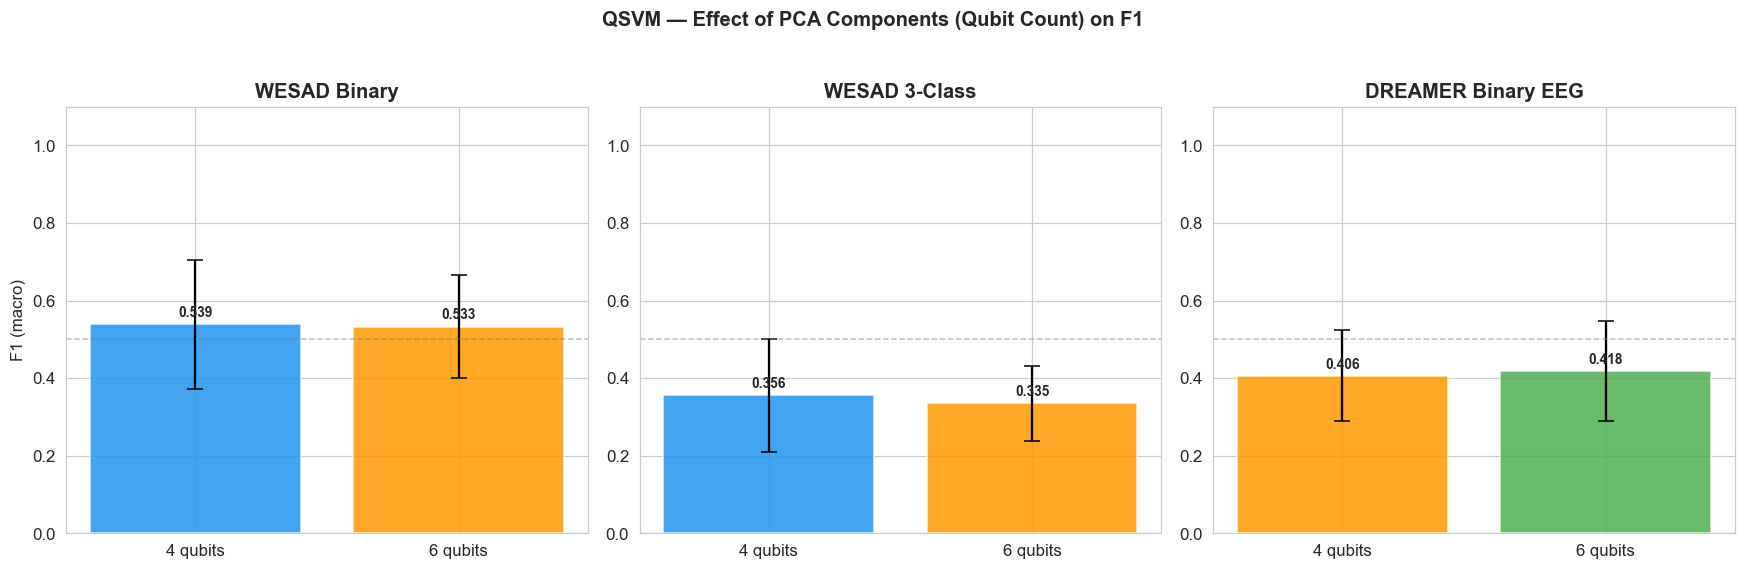

Saved: ..\results\plots\07_qsvm\qsvm_n_qubits_comparison.png


In [45]:
# Effect of n_qubits (PCA components) on F1
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
qubit_colors = {3: '#2196F3', 4: '#FF9800',  6: '#4CAF50'}

for ax, (task_key, task_label, pca_list) in zip(axes, [
        ('WESAD_binary_QSVM',      'WESAD Binary', PCA_COMPONENTS_WESAD),
        ('WESAD_3class_QSVM',      'WESAD 3-Class', PCA_COMPONENTS_WESAD),
        ('DREAMER_binary_EEG_QSVM','DREAMER Binary EEG', PCA_COMPONENTS_DREAMER)]):

    td = all_results[all_results['task']==task_key]
    x  = np.arange(len(pca_list))
    for xi, nq in zip(x, pca_list):
        vals = td[td['n_qubits']==nq]['f1']
        ax.bar(xi, vals.mean(), color=qubit_colors[nq],
               alpha=0.85, yerr=vals.std(), capsize=5,
               label=f'{nq} qubits')
        ax.text(xi, vals.mean()+0.02, f'{vals.mean():.3f}',
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)' if ax == axes[0] else '')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{nq} qubits' for nq in PCA_COMPONENTS])
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5)

plt.suptitle('QSVM — Effect of PCA Components (Qubit Count) on F1',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'qsvm_n_qubits_comparison.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


## 9. Stress/Amusement Overlap Analysis (WESAD 3-Class)

In [46]:
print('=== QSVM Best Config: Stress/Amusement Confusion ===')
cm = best_cm_w3
total_stress = cm[1, :].sum()
total_amuse  = cm[2, :].sum()
s_a = cm[1, 2] / total_stress if total_stress > 0 else 0
a_s = cm[2, 1] / total_amuse  if total_amuse  > 0 else 0
print(f'  Stress -> Amusement : {cm[1,2]}/{total_stress} ({s_a*100:.1f}%)')
print(f'  Amusement -> Stress : {cm[2,1]}/{total_amuse}  ({a_s*100:.1f}%)')

# Load classical overlap for comparison
cl_overlap_path = os.path.join(OUTPUT_DATA_DIR,
                                'classical_stress_amusement_overlap.csv')
if os.path.exists(cl_overlap_path):
    df_cl_overlap = pd.read_csv(cl_overlap_path)
    qsvm_overlap = pd.DataFrame([{
        'model'                  : f'QSVM ({best_cfg_w3})',
        'stress->amusement_rate' : round(s_a, 4),
        'amusement->stress_rate' : round(a_s, 4),
    }])
    combined_overlap = pd.concat([df_cl_overlap, qsvm_overlap],
                                  ignore_index=True)
    print('\n=== Overlap Comparison: Classical vs QSVM ===')
    print(combined_overlap.to_string(index=False))
    p = os.path.join(OUTPUT_DATA_DIR, 'overlap_classical_vs_qsvm.csv')
    combined_overlap.to_csv(p, index=False)
    print(f'\nSaved: {p}')


=== QSVM Best Config: Stress/Amusement Confusion ===
  Stress -> Amusement : 84/313 (26.8%)
  Amusement -> Stress : 37/166  (22.3%)

=== Overlap Comparison: Classical vs QSVM ===
                                                    model  stress->amusement_rate  amusement->stress_rate
                                      Logistic Regression                  0.1150                  0.0482
                                                SVM (RBF)                  0.1246                  0.0602
                                            Random Forest                  0.0511                  0.1145
QSVM (ZZFeatureMap | n_qubits=3 | reps=2 | full | robust)                  0.2684                  0.2229

Saved: ..\results\output_data\overlap_classical_vs_qsvm.csv


## 10. Summary Log

In [47]:
best_results = {}
for task in all_results['task'].unique():
    td = all_results[all_results['task']==task]
    best_row = td.groupby('config')['f1'].mean().idxmax()
    best_data = td[td['config']==best_row]
    best_results[task] = {
        'best_config'   : best_row,
        'f1_mean'       : round(best_data['f1'].mean(), 4),
        'f1_std'        : round(best_data['f1'].std(),  4),
        'accuracy_mean' : round(best_data['accuracy'].mean(), 4),
        'train_time_mean': round(best_data['train_time'].mean(), 2),
    }

summary = {
    'notebook'    : '07_qsvm_experiments',
    'timestamp'   : datetime.now().isoformat(),
    'experiment_grid': {
        'feature_maps' : ['ZZFeatureMap','PauliFeatureMap'],
        'pca_components_wesad'  : PCA_COMPONENTS_WESAD,
        'pca_components_dreamer': PCA_COMPONENTS_DREAMER,
        'reps'         : REPS_LIST,
        'entanglements': ENTANGLEMENTS,
        'scalers'      : SCALER_NAMES,

    },
    'subsampling' : {'n_per_class': N_SAMPLES_PER_CLASS,
                     'applied_to' : 'train fold only'},
    'best_results': best_results,
    'next'        : '08_vqc_experiments.ipynb'
}

p = os.path.join(LOGS_DIR, '07_qsvm_summary.json')
with open(p,'w') as f: json.dump(summary, f, indent=2)

print('=' * 60)
print('QSVM EXPERIMENTS COMPLETE')
print('=' * 60)
print(json.dumps(summary, indent=2))
print(f'\nLog saved: {p}')


QSVM EXPERIMENTS COMPLETE
{
  "notebook": "07_qsvm_experiments",
  "timestamp": "2026-05-10T01:33:37.298554",
  "experiment_grid": {
    "feature_maps": [
      "ZZFeatureMap",
      "PauliFeatureMap"
    ],
    "pca_components_wesad": [
      3,
      4
    ],
    "pca_components_dreamer": [
      4,
      6
    ],
    "reps": [
      1,
      2
    ],
    "entanglements": [
      "linear",
      "full",
      "circular"
    ],
    "scalers": [
      "standard",
      "robust"
    ]
  },
  "subsampling": {
    "n_per_class": 150,
    "applied_to": "train fold only"
  },
  "best_results": {
    "WESAD_binary_QSVM": {
      "best_config": "PauliFeatureMap_n3_r1_linear_robust",
      "f1_mean": 0.6198,
      "f1_std": 0.1954,
      "accuracy_mean": 0.6413,
      "train_time_mean": 0.65
    },
    "WESAD_3class_QSVM": {
      "best_config": "PauliFeatureMap_n3_r2_circular_robust",
      "f1_mean": 0.3898,
      "f1_std": 0.1739,
      "accuracy_mean": 0.423,
      "train_time_mean": 1.61
